<a href="https://colab.research.google.com/github/Susanta2006/Colab/blob/main/Exam_score.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Final optimized values:
m = 16.67663941248961
c = 73.99999987546042


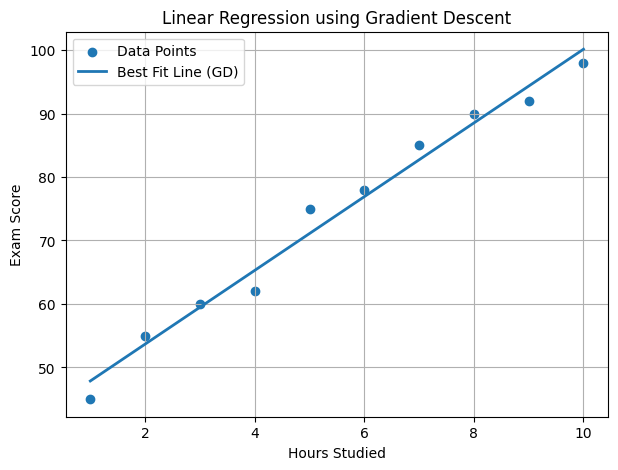

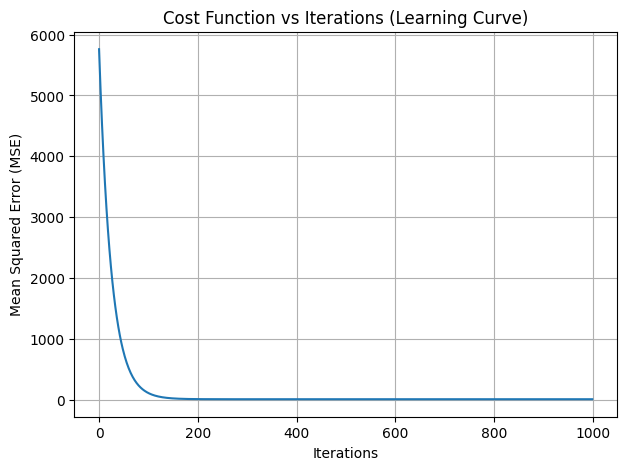

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ============================
# 1. PREPARE THE DATA
# ============================

hours_studied = np.array([1,2,3,4,5,6,7,8,9,10], dtype=float)
exam_scores   = np.array([45,55,60,62,75,78,85,90,92,98], dtype=float)

# Normalize hours to improve Gradient Descent stability
x_mean = hours_studied.mean()
x_std  = hours_studied.std()
x_norm = (hours_studied - x_mean) / x_std

y = exam_scores

# ============================
# 2. GRADIENT DESCENT SETUP
# ============================

m = 0.0
c = 0.0
learning_rate = 0.01
iterations = 1000

cost_history = []

n = len(x_norm)

# ============================
# 3. GRADIENT DESCENT LOOP
# ============================

for i in range(iterations):

    y_pred = m * x_norm + c
    error = y_pred - y

    grad_m = (2/n) * np.dot(error, x_norm)
    grad_c = (2/n) * np.sum(error)

    m -= learning_rate * grad_m
    c -= learning_rate * grad_c

    mse = np.mean(error**2)
    cost_history.append(mse)

# ============================
# 4. PRINT FINAL PARAMETERS
# ============================

print("Final optimized values:")
print("m =", m)
print("c =", c)

# ============================
# 5. PLOT: BEST-FIT LINE
# ============================

# Convert normalized x back to original scale
x_line = np.linspace(hours_studied.min(), hours_studied.max(), 100)
x_line_norm = (x_line - x_mean) / x_std
y_line = m * x_line_norm + c

plt.figure(figsize=(7,5))
plt.scatter(hours_studied, y, label="Data Points")
plt.plot(x_line, y_line, label="Best Fit Line (GD)", linewidth=2)
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Linear Regression using Gradient Descent")
plt.legend()
plt.grid(True)
plt.show()

# ============================
# 6. PLOT: COST HISTORY
# ============================

plt.figure(figsize=(7,5))
plt.plot(range(iterations), cost_history)
plt.xlabel("Iterations")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("Cost Function vs Iterations (Learning Curve)")
plt.grid(True)
plt.show()

High LR (0.5) → m = 16.676639440555856 , c = 74.0
Low LR (0.0001) → m = 0.653964484893429 , c = 2.9018659337579784


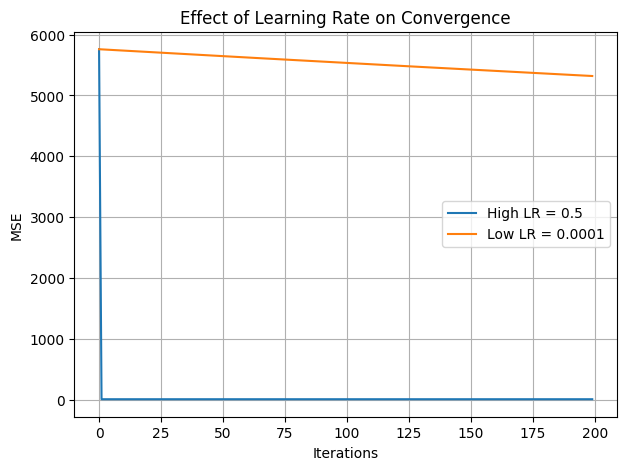

In [4]:
def run_gradient_descent(lr, iters=200):
    m = 0.0
    c = 0.0
    cost_list = []

    for i in range(iters):
        y_pred = m * x_norm + c
        error = y_pred - y

        grad_m = (2/n) * np.dot(error, x_norm)
        grad_c = (2/n) * np.sum(error)

        m -= lr * grad_m
        c -= lr * grad_c

        cost_list.append(np.mean(error**2))

    return m, c, cost_list


# Run for high and low learning rates
m_high, c_high, cost_high = run_gradient_descent(0.5)
m_low,  c_low,  cost_low  = run_gradient_descent(0.0001)

print("High LR (0.5) → m =", m_high, ", c =", c_high)
print("Low LR (0.0001) → m =", m_low, ", c =", c_low)

# Plot comparison
plt.figure(figsize=(7,5))
plt.plot(cost_high, label="High LR = 0.5")
plt.plot(cost_low, label="Low LR = 0.0001")
plt.xlabel("Iterations")
plt.ylabel("MSE")
plt.title("Effect of Learning Rate on Convergence")
plt.legend()
plt.grid(True)
plt.show()

#High Learning Rate (0.5):

	•	The cost oscillates or diverges.
	•	Updates overshoot the minimum.
	•	Model fails to converge or becomes unstable.

#Low Learning Rate (0.0001):
	•	Converges very slowly.
	•	Cost decreases extremely gradually.
	•	Takes many iterations to learn meaningful parameters.

#Optimal Learning Rate (0.01):
	•	Smooth and stable convergence.
	•	Reaches minimum quickly without overshooting.
